# Tesla Deliveries ML Pipeline (2015–2025)
End-to-end pipeline: preprocessing → EDA → feature engineering → regression → hyperparameter tuning → ARIMA forecasting.

## Cell 1 — Install & Import Libraries

In [11]:
# Cell 1: Install & Import Libraries
!pip install pandas numpy matplotlib seaborn scikit-learn statsmodels pmdarima -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('All libraries imported successfully.')

All libraries imported successfully.



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Cell 2 — Load Dataset

In [12]:
# Cell 2: Load Dataset
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nData Types:')
print(df.dtypes)
df.head()

Shape: (2640, 12)

Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Data Types:
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## Cell 3 — Preprocessing & Data Quality Check

In [13]:
# Cell 3: Preprocessing & Data Quality Check
print('=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Duplicate Rows ===')
print(df.duplicated().sum())

print('\n=== Unique Values ===')
print('Models  :', df['Model'].unique())
print('Regions :', df['Region'].unique())
print('Years   :', sorted(df['Year'].unique()))
print('Source  :', df['Source_Type'].unique())

print('\n=== Statistical Summary ===')
df.describe().round(2)

=== Missing Values ===
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

=== Duplicate Rows ===
0

=== Unique Values ===
Models  : ['Model S' 'Model X' 'Model 3' 'Model Y' 'Cybertruck']
Regions : ['Europe' 'Asia' 'North America' 'Middle East']
Years   : [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Source  : ['Interpolated (Month)' 'Official (Quarter)' 'Estimated (Region)']

=== Statistical Summary ===


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00
mean,2020.00,6.50,9922.20,10655.85,84907.34,87.06,500.26,744.08,8932.13
std,3.16,3.45,3935.95,4260.60,20123.26,20.84,120.87,353.22,3469.57
min,2015.00,1.00,48.00,50.00,50003.70,60.00,330.00,3.07,3002.00
25%,2017.00,3.75,7292.00,7828.25,67726.36,75.00,418.00,499.62,5897.75
50%,2020.00,6.50,9857.00,10546.50,85058.51,82.00,470.00,699.52,8901.50
75%,2023.00,9.25,12510.25,13469.00,102373.04,100.00,586.25,943.76,11938.00
max,2025.00,12.00,25704.00,28939.00,119965.36,120.00,719.00,2548.55,14996.00


## Cell 4 — EDA: Delivery Distribution

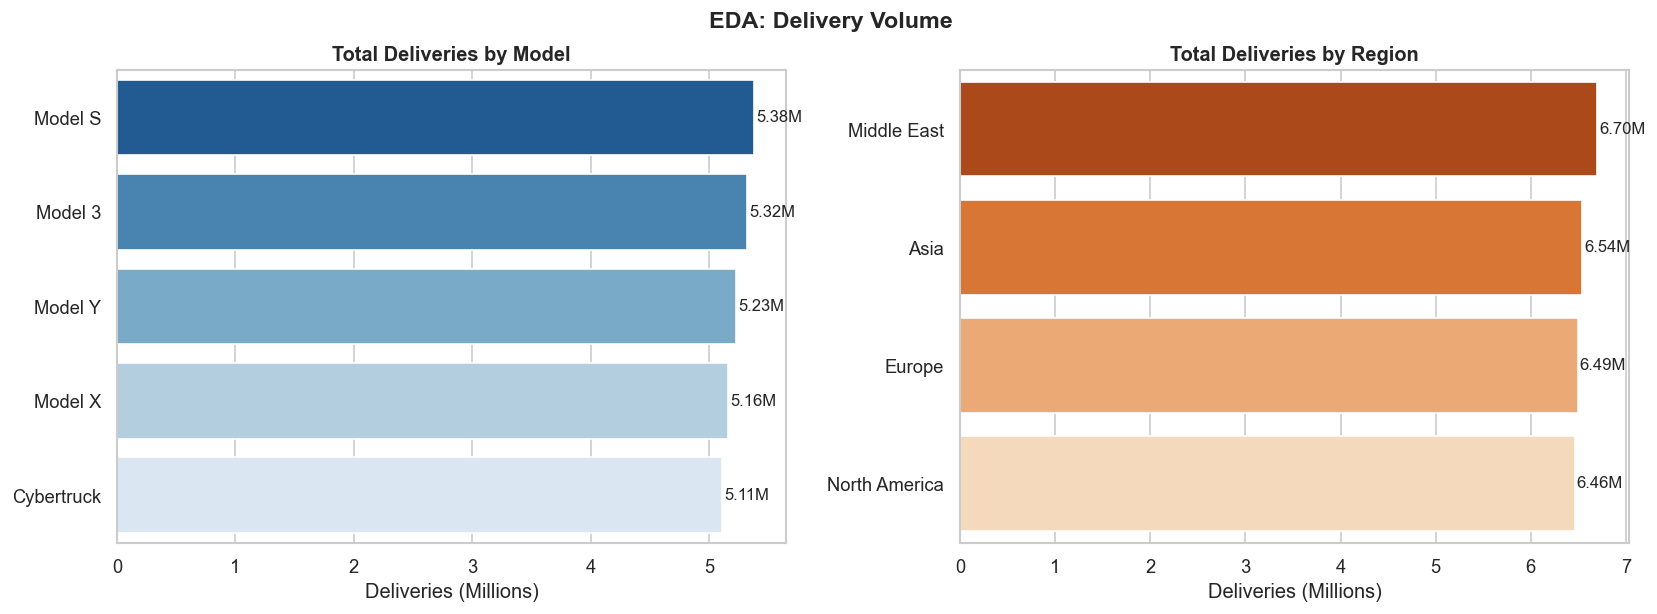

In [14]:
# Cell 4: EDA — Delivery Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By Model
model_del = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=False)
sns.barplot(x=model_del.values / 1e6, y=model_del.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Total Deliveries by Model', fontweight='bold')
axes[0].set_xlabel('Deliveries (Millions)')
axes[0].set_ylabel('')
for i, v in enumerate(model_del.values):
    axes[0].text(v/1e6 + 0.02, i, f'{v/1e6:.2f}M', va='center', fontsize=10)

# By Region
region_del = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=False)
sns.barplot(x=region_del.values / 1e6, y=region_del.index, ax=axes[1], palette='Oranges_r')
axes[1].set_title('Total Deliveries by Region', fontweight='bold')
axes[1].set_xlabel('Deliveries (Millions)')
axes[1].set_ylabel('')
for i, v in enumerate(region_del.values):
    axes[1].text(v/1e6 + 0.02, i, f'{v/1e6:.2f}M', va='center', fontsize=10)

plt.tight_layout()
plt.suptitle('EDA: Delivery Volume', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## Cell 5 — EDA: Yearly Trends

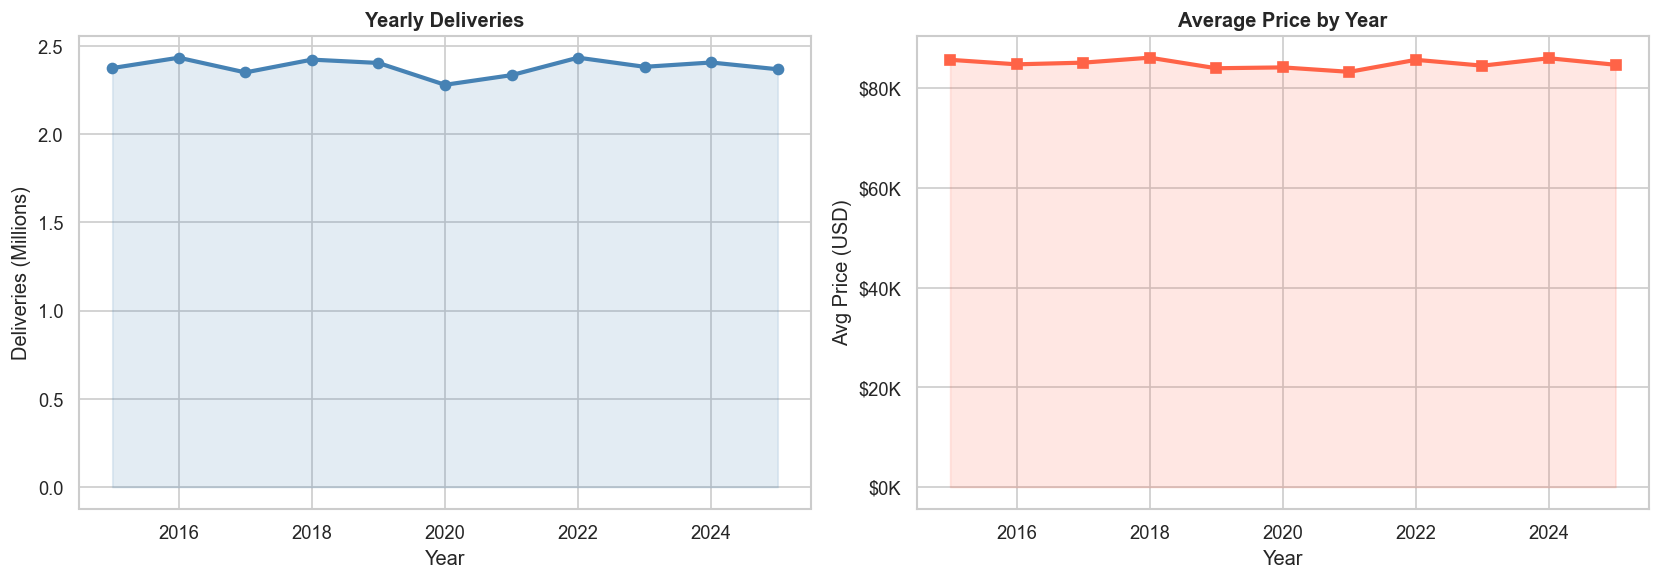

In [15]:
# Cell 5: EDA — Yearly Trends
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Deliveries over years
yearly = df.groupby('Year')['Estimated_Deliveries'].sum()
axes[0].plot(yearly.index, yearly.values / 1e6, marker='o', color='steelblue', linewidth=2.5, markersize=6)
axes[0].fill_between(yearly.index, yearly.values / 1e6, alpha=0.15, color='steelblue')
axes[0].set_title('Yearly Deliveries', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Deliveries (Millions)')
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Avg price over years
price_yr = df.groupby('Year')['Avg_Price_USD'].mean()
axes[1].plot(price_yr.index, price_yr.values, marker='s', color='tomato', linewidth=2.5, markersize=6)
axes[1].fill_between(price_yr.index, price_yr.values, alpha=0.15, color='tomato')
axes[1].set_title('Average Price by Year', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Avg Price (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

## Cell 6 — EDA: Correlation Heatmap

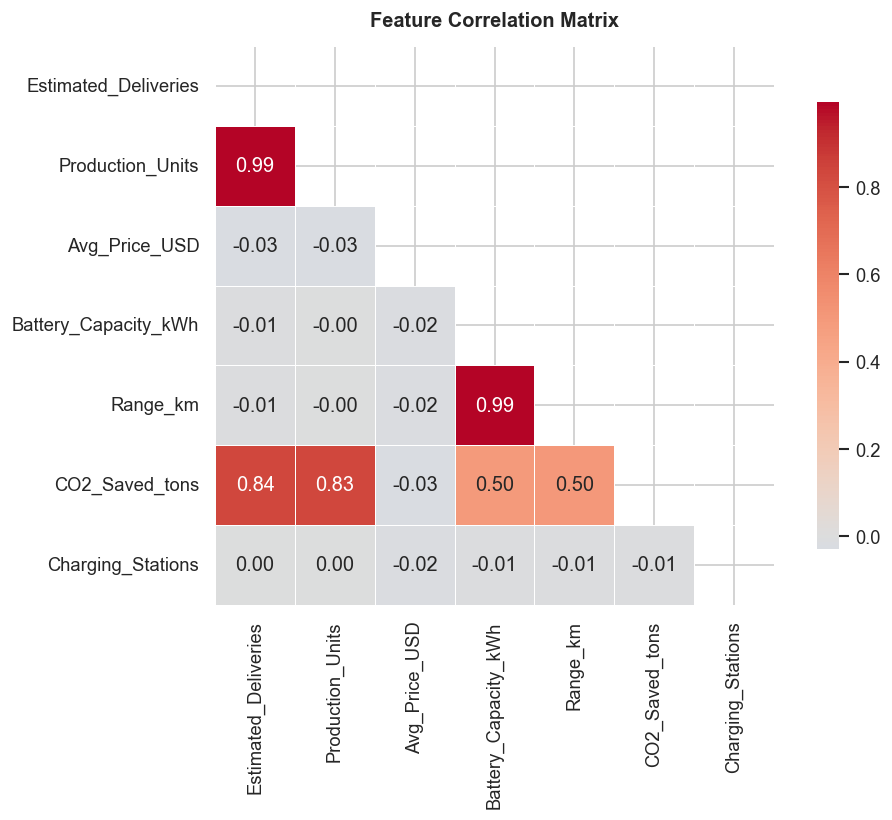

In [16]:
# Cell 6: EDA — Correlation Heatmap
numeric_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
                'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## Cell 7 — EDA: Price Distribution by Model

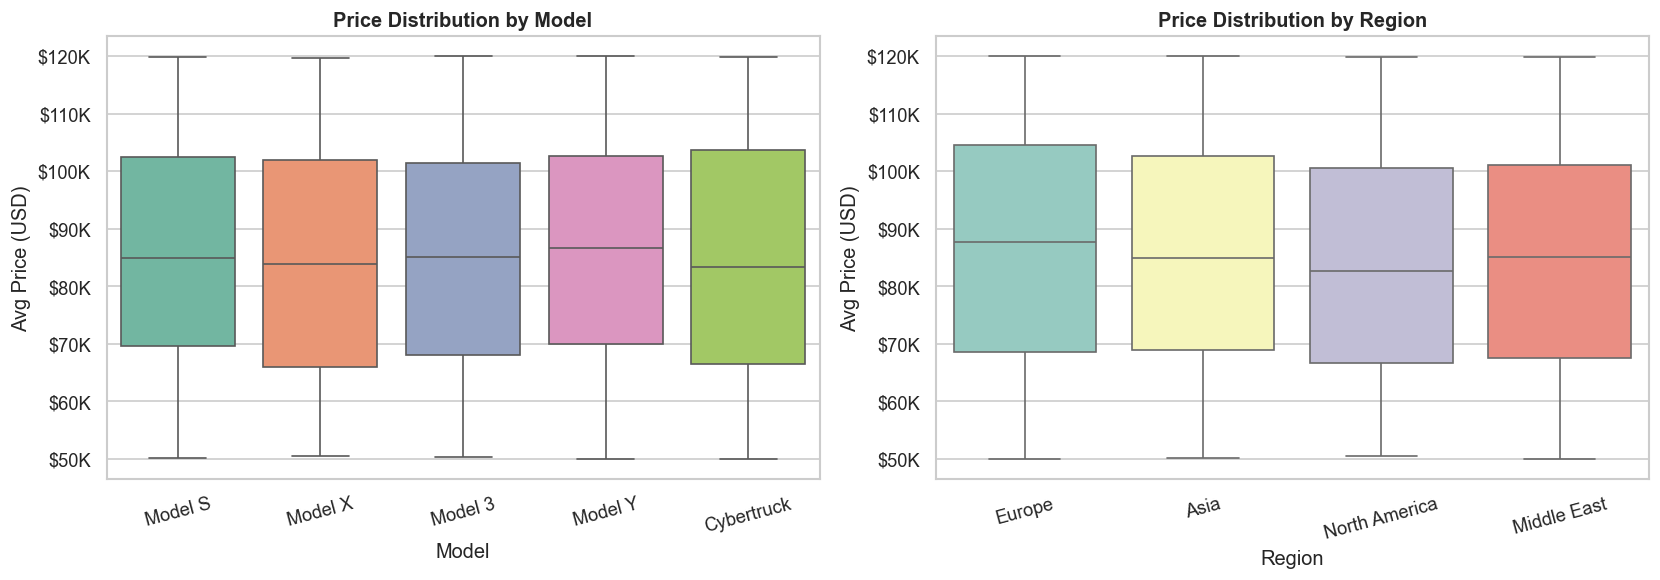

In [17]:
# Cell 7: EDA — Price Distribution by Model & Region
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Model', y='Avg_Price_USD', ax=axes[0], palette='Set2')
axes[0].set_title('Price Distribution by Model', fontweight='bold')
axes[0].set_ylabel('Avg Price (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(data=df, x='Region', y='Avg_Price_USD', ax=axes[1], palette='Set3')
axes[1].set_title('Price Distribution by Region', fontweight='bold')
axes[1].set_ylabel('Avg Price (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Cell 8 — Feature Engineering

In [18]:
# Cell 8: Feature Engineering
df = df.copy()

# Ratio features
df['Production_Efficiency'] = df['Estimated_Deliveries'] / df['Production_Units']
df['Price_per_km']          = df['Avg_Price_USD'] / df['Range_km']
df['CO2_per_delivery']      = df['CO2_Saved_tons'] / df['Estimated_Deliveries']

# Time features
df['Quarter']        = ((df['Month'] - 1) // 3) + 1
df['Is_Q4']          = (df['Quarter'] == 4).astype(int)
df['Year_Since_Start'] = df['Year'] - 2015

# Cyclical encoding for month
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# Label encoding
le_model  = LabelEncoder()
le_region = LabelEncoder()
df['Model_enc']  = le_model.fit_transform(df['Model'])
df['Region_enc'] = le_region.fit_transform(df['Region'])

print('New features added:')
new_feats = ['Production_Efficiency','Price_per_km','CO2_per_delivery',
             'Quarter','Is_Q4','Year_Since_Start','Month_sin','Month_cos',
             'Model_enc','Region_enc']
print(df[new_feats].describe().round(3))

New features added:
       Production_Efficiency  Price_per_km  CO2_per_delivery   Quarter  \
count               2640.000      2640.000          2640.000  2640.000   
mean                   0.933       180.046             0.075     2.500   
std                    0.037        61.894             0.018     1.118   
min                    0.870        69.902             0.049     1.000   
25%                    0.900       132.532             0.063     1.750   
50%                    0.932       170.357             0.071     2.500   
75%                    0.964       219.097             0.088     3.250   
max                    1.000       359.378             0.108     4.000   

          Is_Q4  Year_Since_Start  Month_sin  Month_cos  Model_enc  Region_enc  
count  2640.000          2640.000   2640.000   2640.000   2640.000    2640.000  
mean      0.250             5.000     -0.000     -0.000      2.000       1.500  
std       0.433             3.163      0.707      0.707      1.414    

## Cell 9 — Train/Test Split & Scaling

In [19]:
# Cell 9: Train/Test Split & Scaling
FEATURES = [
    'Year_Since_Start', 'Month_sin', 'Month_cos', 'Quarter', 'Is_Q4',
    'Estimated_Deliveries', 'Production_Units', 'Battery_Capacity_kWh',
    'Range_km', 'Charging_Stations', 'Production_Efficiency',
    'Price_per_km', 'CO2_per_delivery', 'Model_enc', 'Region_enc'
]
TARGET = 'Avg_Price_USD'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train size : {X_train.shape[0]} samples')
print(f'Test size  : {X_test.shape[0]} samples')
print(f'Features   : {len(FEATURES)}')

Train size : 2112 samples
Test size  : 528 samples
Features   : 15


## Cell 10 — Train Multiple Regression Models

In [20]:
# Cell 10: Train Multiple Regression Models
models = {
    'Linear Regression' : LinearRegression(),
    'Ridge'             : Ridge(alpha=1.0),
    'Lasso'             : Lasso(alpha=0.1),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    results[name] = {
        'R2'  : round(r2_score(y_test, preds), 4),
        'MAE' : round(mean_absolute_error(y_test, preds), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, preds)), 2),
    }

results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
print('=== Model Comparison ===')
print(results_df.to_string())

=== Model Comparison ===
                       R2      MAE     RMSE
Random Forest      0.9979   645.88   883.27
Gradient Boosting  0.9933  1211.77  1595.24
Linear Regression  0.8995  5004.53  6157.57
Lasso              0.8995  5005.19  6156.56
Ridge              0.8995  5005.67  6156.64


## Cell 11 — Model Comparison Chart

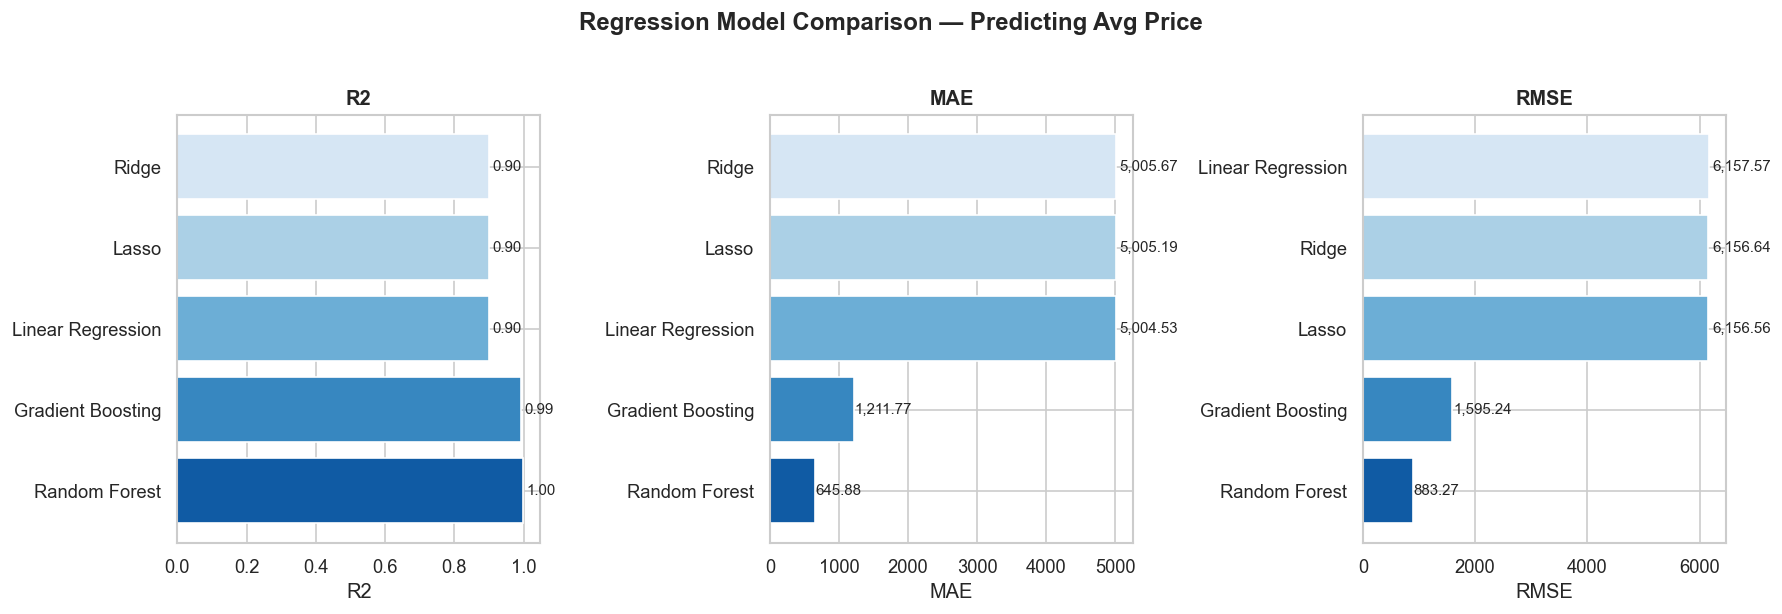

In [21]:
# Cell 11: Model Comparison Chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['R2', 'MAE', 'RMSE']
colors = sns.color_palette('Blues_r', len(results_df))

for i, metric in enumerate(metrics):
    data = results_df[metric].sort_values(ascending=(metric != 'R2'))
    bars = axes[i].barh(data.index, data.values, color=colors)
    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_xlabel(metric)
    for bar, val in zip(bars, data.values):
        axes[i].text(val * 1.01, bar.get_y() + bar.get_height() / 2,
                     f'{val:,.2f}', va='center', fontsize=9)

plt.suptitle('Regression Model Comparison — Predicting Avg Price', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Cell 12 — Hyperparameter Tuning (GridSearchCV)

In [22]:
# Cell 12: Hyperparameter Tuning with GridSearchCV
param_grid = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5],
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)
grid_search.fit(X_train_s, y_train)

print('Best Parameters :', grid_search.best_params_)
print('Best CV R²       :', round(grid_search.best_score_, 4))

best_rf   = grid_search.best_estimator_
best_preds = best_rf.predict(X_test_s)

print('\n=== Tuned RF on Test Set ===')
print(f'R²   : {r2_score(y_test, best_preds):.4f}')
print(f'MAE  : ${mean_absolute_error(y_test, best_preds):,.2f}')
print(f'RMSE : ${np.sqrt(mean_squared_error(y_test, best_preds)):,.2f}')

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Parameters : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R²       : 0.9965

=== Tuned RF on Test Set ===
R²   : 0.9980
MAE  : $637.61
RMSE : $875.53


## Cell 13 — Feature Importance

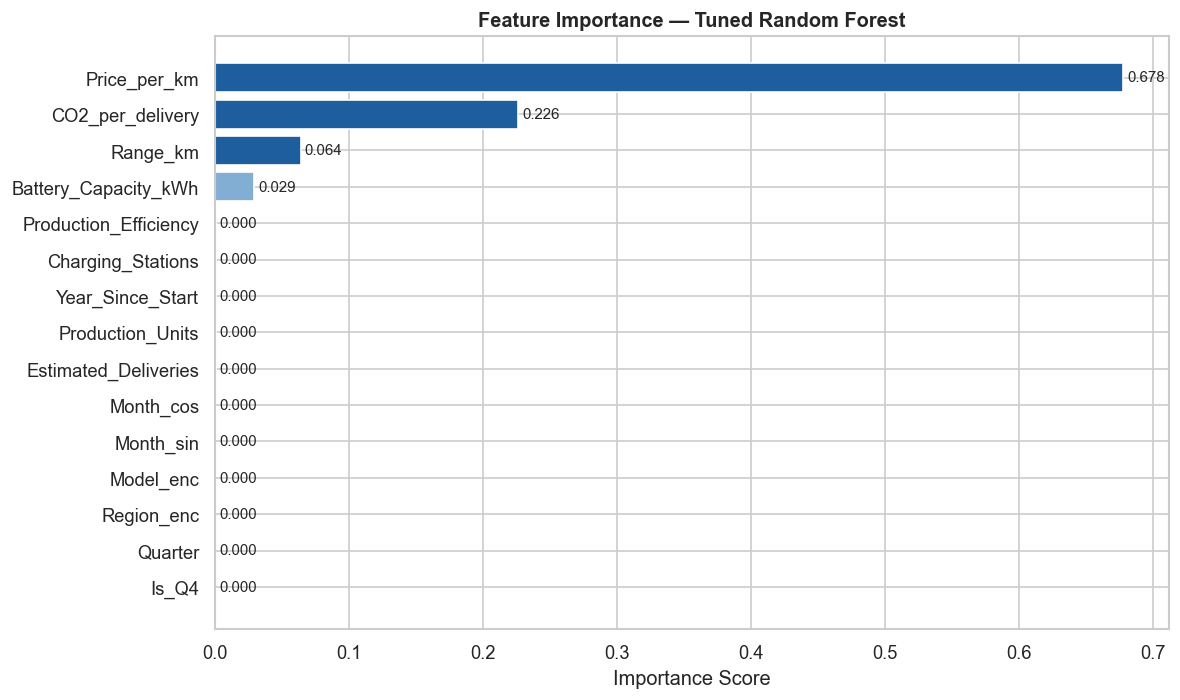


Top 5 Features:
Price_per_km             0.678014
CO2_per_delivery         0.226288
Range_km                 0.063920
Battery_Capacity_kWh     0.029316
Production_Efficiency    0.000423
dtype: float64


In [23]:
# Cell 13: Feature Importance from Tuned Random Forest
importances = pd.Series(best_rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#1f5e9e' if v > 0.05 else '#82aed4' for v in importances.values]
bars = plt.barh(importances.index[::-1], importances.values[::-1], color=colors[::-1])
plt.xlabel('Importance Score')
plt.title('Feature Importance — Tuned Random Forest', fontweight='bold')
for bar, val in zip(bars, importances.values[::-1]):
    plt.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nTop 5 Features:')
print(importances.head())

## Cell 14 — Actual vs Predicted Plot

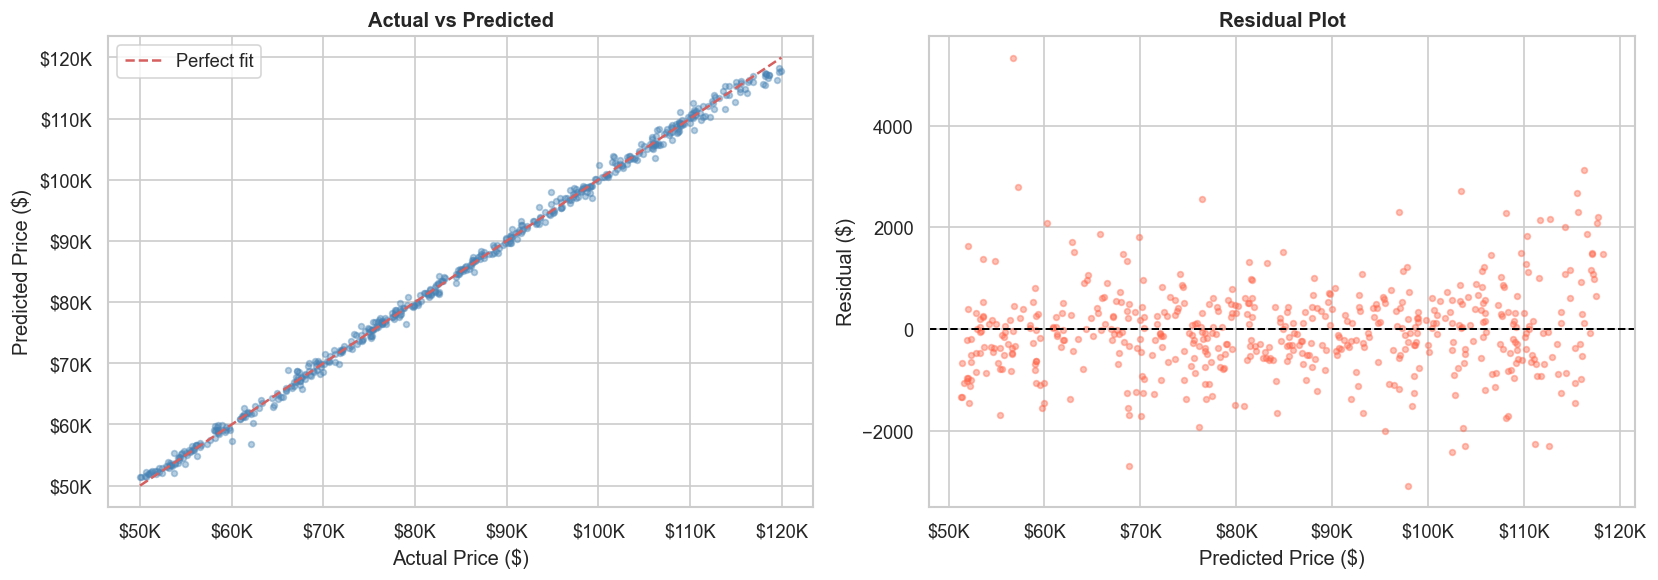

In [24]:
# Cell 14: Actual vs Predicted — Tuned RF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(y_test, best_preds, alpha=0.4, color='steelblue', s=12)
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title('Actual vs Predicted', fontweight='bold')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Residuals
residuals = y_test - best_preds
axes[1].scatter(best_preds, residuals, alpha=0.4, color='tomato', s=12)
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residual ($)')
axes[1].set_title('Residual Plot', fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.show()

## Cell 15 — Time Series Preparation

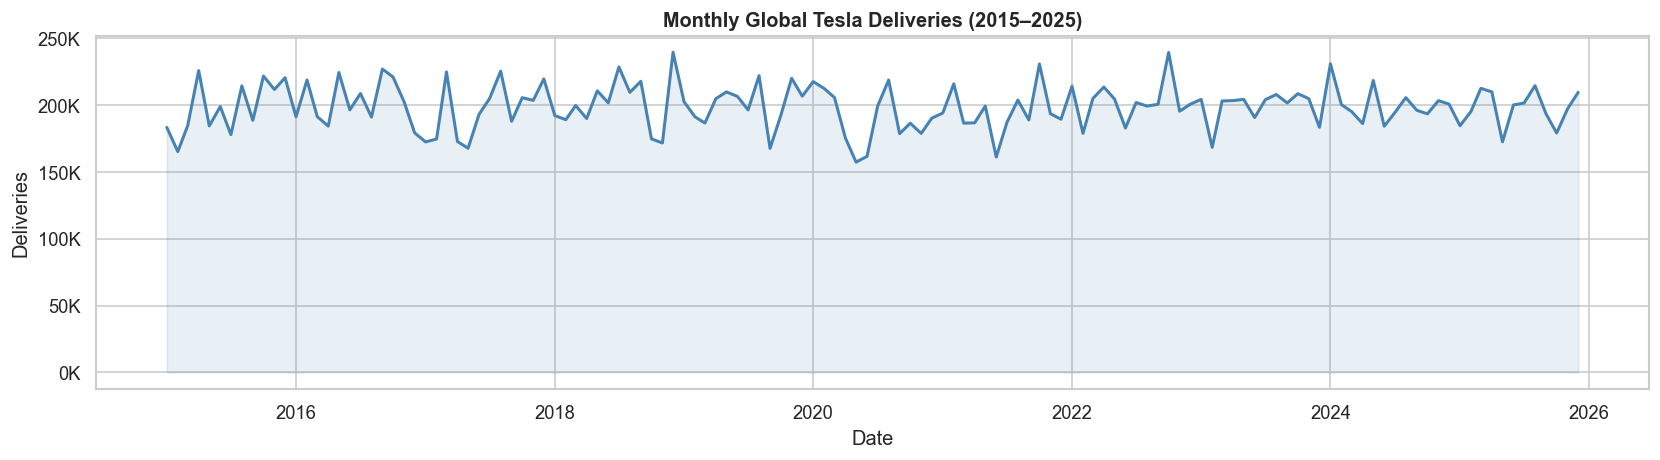

Time series length: 132


In [25]:
# Cell 15: Time Series Preparation
ts = (
    df.groupby(['Year', 'Month'])['Estimated_Deliveries']
      .sum()
      .reset_index()
      .sort_values(['Year', 'Month'])
)
ts['Date'] = pd.to_datetime(ts[['Year','Month']].assign(day=1))
ts = ts.set_index('Date')

plt.figure(figsize=(14, 4))
plt.plot(ts.index, ts['Estimated_Deliveries'], color='steelblue', linewidth=1.8)
plt.fill_between(ts.index, ts['Estimated_Deliveries'], alpha=0.12, color='steelblue')
plt.title('Monthly Global Tesla Deliveries (2015–2025)', fontweight='bold')
plt.ylabel('Deliveries')
plt.xlabel('Date')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.show()

print('Time series length:', len(ts))

## Cell 16 — Stationarity Test (ADF)

In [26]:
# Cell 16: ADF Stationarity Test
ts_vals = ts['Estimated_Deliveries'].values.astype(float)

adf_result = adfuller(ts_vals)
print('=== Augmented Dickey-Fuller Test ===')
print(f'ADF Statistic : {adf_result[0]:.4f}')
print(f'p-value       : {adf_result[1]:.6f}')
print(f'Critical Values:')
for key, val in adf_result[4].items():
    print(f'   {key}: {val:.4f}')

if adf_result[1] < 0.05:
    print('\n✓ Series is STATIONARY (reject H0 at 5% significance)')
else:
    print('\n✗ Series is NON-STATIONARY — differencing required')

=== Augmented Dickey-Fuller Test ===
ADF Statistic : -8.8810
p-value       : 0.000000
Critical Values:
   1%: -3.4817
   5%: -2.8840
   10%: -2.5788

✓ Series is STATIONARY (reject H0 at 5% significance)


## Cell 17 — ACF / PACF Plots

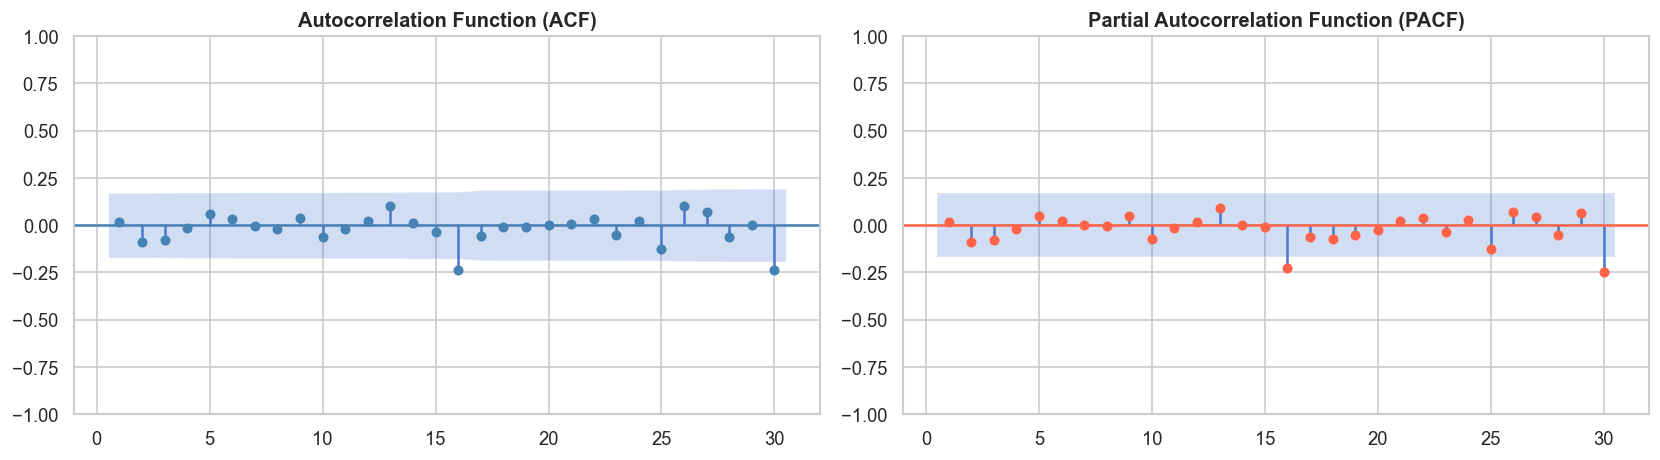

In [27]:
# Cell 17: ACF and PACF Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts_vals, lags=30, ax=axes[0], color='steelblue', zero=False)
axes[0].set_title('Autocorrelation Function (ACF)', fontweight='bold')

plot_pacf(ts_vals, lags=30, ax=axes[1], color='tomato', method='ywm', zero=False)
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontweight='bold')

plt.tight_layout()
plt.show()

## Cell 18 — Fit ARIMA Model

In [28]:
# Cell 18: Fit ARIMA(2,1,2) Model
arima_model = ARIMA(ts_vals, order=(2, 1, 2))
arima_fit   = arima_model.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  132
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -1490.869
Date:                Sun, 07 Jun 2026   AIC                           2991.738
Time:                        10:39:46   BIC                           3006.114
Sample:                             0   HQIC                          2997.579
                                - 132                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2137      1.068      0.200      0.841      -1.879       2.307
ar.L2          0.0365      0.193      0.189      0.850      -0.342       0.415
ma.L1         -0.7846      1.082     -0.725      0.4

## Cell 19 — ARIMA Forecast (12 Months)

In [29]:
# Cell 19: ARIMA 12-Month Forecast
FORECAST_STEPS = 12
fc_obj    = arima_fit.get_forecast(steps=FORECAST_STEPS)
fc_mean   = fc_obj.predicted_mean
fc_ci     = fc_obj.conf_int()

# Build forecast dates
last_date  = ts.index[-1]
fc_dates   = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=FORECAST_STEPS, freq='MS')

print('=== 12-Month Forecast ===')
fc_df = pd.DataFrame({
    'Date'       : fc_dates,
    'Forecast'   : fc_mean.round(0).astype(int),
    'Lower_95CI' : fc_ci[:, 0].round(0).astype(int),
    'Upper_95CI' : fc_ci[:, 1].round(0).astype(int),
})
print(fc_df.to_string(index=False))

=== 12-Month Forecast ===
      Date  Forecast  Lower_95CI  Upper_95CI
2026-01-01    201435      166691      236178
2026-02-01    200329      162522      238135
2026-03-01    199802      160047      239557
2026-04-01    199649      158398      240900
2026-05-01    199597      156996      242198
2026-06-01    199580      155701      243459
2026-07-01    199575      154463      244687
2026-08-01    199573      153265      245882
2026-09-01    199572      152098      247047
2026-10-01    199572      150961      248184
2026-11-01    199572      149849      249295
2026-12-01    199572      148762      250382


## Cell 20 — ARIMA Forecast Plot

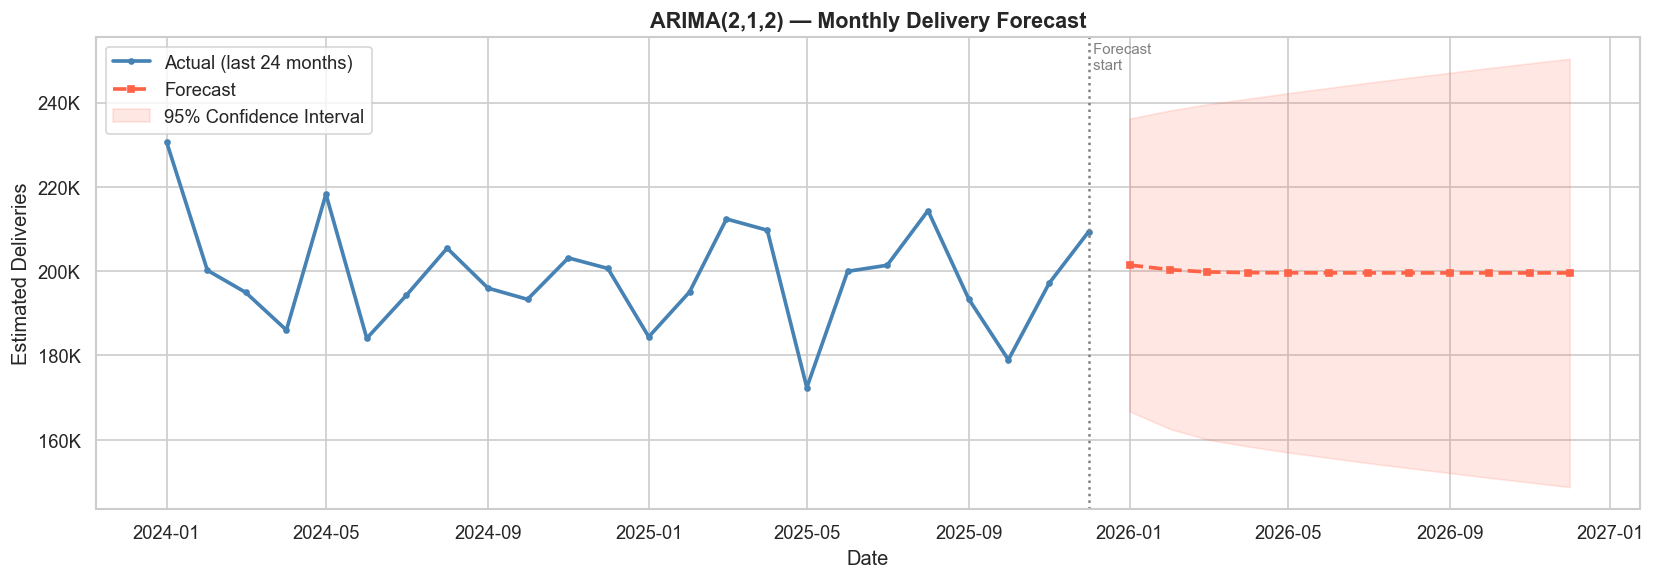

In [30]:
# Cell 20: ARIMA Forecast Plot — Last 24 actuals + 12-month forecast
last24     = ts.index[-24:]
last24_vals = ts['Estimated_Deliveries'].values[-24:]

plt.figure(figsize=(14, 5))

plt.plot(last24, last24_vals, color='steelblue', linewidth=2.2, label='Actual (last 24 months)', marker='o', markersize=3)
plt.plot(fc_dates, fc_mean, color='tomato', linewidth=2.2, linestyle='--', label='Forecast', marker='s', markersize=4)
plt.fill_between(fc_dates, fc_ci[:, 0], fc_ci[:, 1], color='tomato', alpha=0.15, label='95% Confidence Interval')

plt.axvline(x=last24[-1], color='gray', linestyle=':', linewidth=1.5)
plt.text(last24[-1], plt.ylim()[1] * 0.97, ' Forecast\n start', color='gray', fontsize=9)

plt.title('ARIMA(2,1,2) — Monthly Delivery Forecast', fontweight='bold', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.legend()
plt.tight_layout()
plt.show()

## Cell 21 — Pipeline Summary

In [31]:
# Cell 21: Full Pipeline Summary
print('=' * 55)
print('        TESLA ML PIPELINE — FINAL SUMMARY')
print('=' * 55)

print('\n[Dataset]')
print(f'  Records  : {df.shape[0]:,}')
print(f'  Features : {df.shape[1]}')
print(f'  Period   : 2015 – 2025')
print(f'  Models   : {df["Model"].nunique()} | Regions: {df["Region"].nunique()}')

print('\n[Feature Engineering]')
print('  10 new features: ratios, time, cyclical encoding, label encoding')

print('\n[Regression — Predict Avg Price]')
for model_name, m in results.items():
    tag = ' ← best' if model_name == 'Random Forest' else ''
    print(f'  {model_name:<22} R²={m["R2"]}  MAE=${m["MAE"]:,.0f}{tag}')

print('\n[Hyperparameter Tuning — GridSearchCV]')
print(f'  Best params : {grid_search.best_params_}')
print(f'  Tuned R²    : {r2_score(y_test, best_preds):.4f}')
print(f'  Tuned MAE   : ${mean_absolute_error(y_test, best_preds):,.2f}')
print(f'  Tuned RMSE  : ${np.sqrt(mean_squared_error(y_test, best_preds)):,.2f}')

print('\n[ARIMA Time Series Forecast]')
print(f'  Order      : (2, 1, 2)')
print(f'  ADF p-val  : {adf_result[1]:.6f} (stationary)')
print(f'  AIC / BIC  : {arima_fit.aic:.1f} / {arima_fit.bic:.1f}')
print(f'  Forecast+1 : {fc_mean[0]:,.0f} units  (95% CI: {fc_ci[0,0]:,.0f}–{fc_ci[0,1]:,.0f})')
print('=' * 55)

        TESLA ML PIPELINE — FINAL SUMMARY

[Dataset]
  Records  : 2,640
  Features : 22
  Period   : 2015 – 2025
  Models   : 5 | Regions: 4

[Feature Engineering]
  10 new features: ratios, time, cyclical encoding, label encoding

[Regression — Predict Avg Price]
  Linear Regression      R²=0.8995  MAE=$5,005
  Ridge                  R²=0.8995  MAE=$5,006
  Lasso                  R²=0.8995  MAE=$5,005
  Random Forest          R²=0.9979  MAE=$646 ← best
  Gradient Boosting      R²=0.9933  MAE=$1,212

[Hyperparameter Tuning — GridSearchCV]
  Best params : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  Tuned R²    : 0.9980
  Tuned MAE   : $637.61
  Tuned RMSE  : $875.53

[ARIMA Time Series Forecast]
  Order      : (2, 1, 2)
  ADF p-val  : 0.000000 (stationary)
  AIC / BIC  : 2991.7 / 3006.1
  Forecast+1 : 201,435 units  (95% CI: 166,691–236,178)
